### New implementation

In [80]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize
import os
import shutil
def setup_latex_environment():
    tex_bin = "/sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux"
    if shutil.which("latex") or os.path.exists(tex_bin):
        os.environ["PATH"] = tex_bin + ":" + os.environ["PATH"]
        os.environ["TEXMFVAR"] = os.path.expanduser("~/.cache/texmf")
        print("LaTeX environment configured")
        print("latex:", shutil.which("latex"))
        print("dvipng:", shutil.which("dvipng"))
        print("gs:", shutil.which("gs"))
    else:
        print("LaTeX not found")
from tueplots import bundles
plt.style.use(bundles.icml2022())
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 14,
    "lines.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
%matplotlib inline
setup_latex_environment()

LaTeX environment configured
latex: /sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux/latex
dvipng: /sw/rl9c/texlive/2022/rl9_binary/install-tl-20221109/bin/x86_64-linux/dvipng
gs: /usr/bin/gs


/tmp/ipykernel_678635/1088900038.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


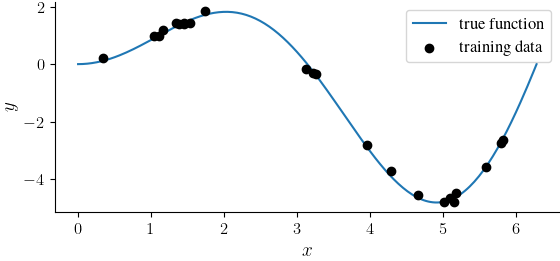

In [29]:
def true_function(x):
    return x * np.sin(x)


def make_qgp_1d_data(
    n_train=23,
    n_test=200,
    noise_std=0.1,
    seed=0,
):
    rng = np.random.default_rng(seed)

    # Non-equidistant training points in [0, 2pi]
    X_train = np.sort(rng.uniform(0.0, 2.0 * np.pi, size=n_train))[:, None]
    y_clean = true_function(X_train[:, 0])
    y_train = y_clean + noise_std * rng.normal(size=n_train)

    # Dense test grid
    X_test = np.linspace(0.0, 2.0 * np.pi, n_test)[:, None]
    y_test_clean = true_function(X_test[:, 0])

    return X_train, y_train, X_test, y_test_clean


X_train_raw, y_train_raw, X_test_raw, y_test_clean_raw = make_qgp_1d_data(
    n_train=23,
    n_test=200,
    noise_std=0.1,
    seed=123,
)

plt.figure(figsize=(6, 3))
plt.plot(X_test_raw[:, 0], y_test_clean_raw, label="true function")
plt.scatter(X_train_raw[:, 0], y_train_raw, color="k", zorder=3, label="training data")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
x_scaler = MinMaxScaler(feature_range=(-1.0, 1.0))

X_train = x_scaler.fit_transform(X_train_raw)
X_test = x_scaler.transform(X_test_raw)

# Standardize targets for numerical stability
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train_raw[:, None]).ravel()
y_test_clean = y_scaler.transform(y_test_clean_raw[:, None]).ravel()

In [31]:
def chebyshev_qgp_feature_map(x_scalar, theta, n_qubits=4, n_layers=2):
    """
    Hardware-efficient Chebyshev-inspired feature map.

    x_scalar should be in [-1, 1].
    theta has shape [n_layers, 2 * n_qubits].

    For each layer and qubit:
        Ry(theta_i)
        Rx(theta_i * arccos(x))
        Rz(theta_{n_qubits+i})
        Ry(theta_i)
    """
    x_scalar = float(np.clip(x_scalar, -1.0, 1.0))

    theta = np.asarray(theta).reshape(n_layers, 2 * n_qubits)

    qc = QuantumCircuit(n_qubits)

    angle_x = np.arccos(x_scalar)

    for layer in range(n_layers):
        theta_layer = theta[layer]

        for q in range(n_qubits):
            theta_y = theta_layer[q]
            theta_z = theta_layer[n_qubits + q]

            qc.ry(theta_y, q)
            qc.rx(theta_y * angle_x, q)
            qc.rz(theta_z, q)
            qc.ry(theta_y, q)

    return qc

Depth: 12


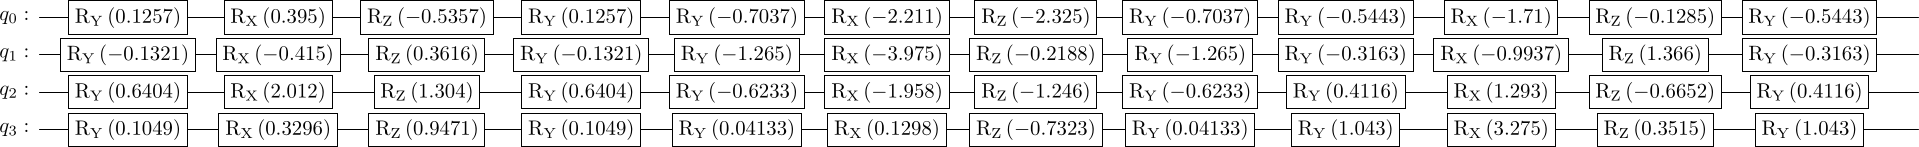

In [46]:
n_qubits = 4
n_layers = 3

rng = np.random.default_rng(0)
theta0 = rng.normal(loc=0.0, scale=1.0, size=(n_layers, 2 * n_qubits))

qc = chebyshev_qgp_feature_map(
    x_scalar=X_train[0, 0],
    theta=theta0,
    n_qubits=n_qubits,
    n_layers=n_layers,
)

print("Depth:", qc.decompose().depth())
qc.draw("latex")

In [47]:
def compute_statevectors(X, theta, n_qubits=4, n_layers=2):
    """
    Compute statevectors |phi(x; theta)> for all x in X.
    X shape: [n_points, 1]
    Returns array of shape [n_points, 2**n_qubits].
    """
    states = []

    for x in X[:, 0]:
        qc = chebyshev_qgp_feature_map(
            x_scalar=x,
            theta=theta,
            n_qubits=n_qubits,
            n_layers=n_layers,
        )
        state = Statevector.from_instruction(qc).data
        states.append(state)

    return np.asarray(states)


def quantum_kernel_from_states(states_A, states_B):
    """
    K_ij = |<state_B_j | state_A_i>|^2

    states_A shape: [n_A, dim]
    states_B shape: [n_B, dim]
    returns K shape: [n_A, n_B]
    """
    overlaps = states_A @ states_B.conj().T
    K = np.abs(overlaps) ** 2
    return K


def quantum_kernel_matrix(XA, XB, theta, n_qubits=4, n_layers=2):
    states_A = compute_statevectors(XA, theta, n_qubits=n_qubits, n_layers=n_layers)
    states_B = compute_statevectors(XB, theta, n_qubits=n_qubits, n_layers=n_layers)
    return quantum_kernel_from_states(states_A, states_B)

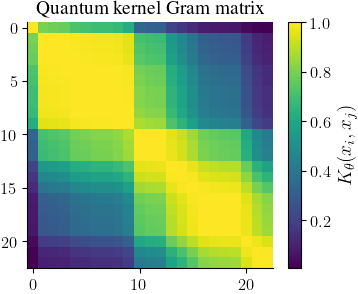

In [48]:
K_train = quantum_kernel_matrix(
    X_train,
    X_train,
    theta0,
    n_qubits=n_qubits,
    n_layers=n_layers,
)

plt.figure(figsize=(4, 3))
plt.imshow(K_train)
plt.colorbar(label=r"$K_\theta(x_i,x_j)$")
plt.title("Quantum kernel Gram matrix")
#plt.tight_layout()
plt.show()

In [49]:
def psd_project(K, eps=1e-10):
    """
    Project a symmetric matrix to the PSD cone by clipping eigenvalues.
    """
    K = 0.5 * (K + K.T)

    eigvals, eigvecs = np.linalg.eigh(K)
    eigvals_clipped = np.clip(eigvals, eps, None)

    K_psd = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T
    K_psd = 0.5 * (K_psd + K_psd.T)

    return K_psd

In [50]:
def gp_posterior_from_kernel(
    K_train,
    K_test_train,
    K_test_test,
    y_train,
    noise_var=1e-2,
    jitter=1e-8,
):
    """
    GP posterior using precomputed kernels.

    K_train:      [n_train, n_train]
    K_test_train: [n_test, n_train]
    K_test_test:  [n_test, n_test]
    """
    n_train = K_train.shape[0]

    Ky = K_train + (noise_var + jitter) * np.eye(n_train)

    c_factor = cho_factor(Ky, lower=True, check_finite=False)
    alpha = cho_solve(c_factor, y_train, check_finite=False)

    mean = K_test_train @ alpha

    v = cho_solve(c_factor, K_test_train.T, check_finite=False)
    cov = K_test_test - K_test_train @ v
    cov = 0.5 * (cov + cov.T)

    var = np.clip(np.diag(cov), 1e-12, None)

    return mean, var, cov

In [59]:
noise_std_scaled = 0.1 / y_scaler.scale_[0]
noise_var = noise_std_scaled ** 2
print(f"Noise std (scaled): {noise_std_scaled:.4f}, Noise var: {noise_var:.4f}")

signal_var = 1.0
K_train = signal_var * quantum_kernel_matrix(X_train, X_train, theta0, n_qubits, n_layers)
K_test_train = signal_var * quantum_kernel_matrix(X_test, X_train, theta0, n_qubits, n_layers)
K_test_test = signal_var * quantum_kernel_matrix(X_test, X_test, theta0, n_qubits, n_layers)

# K_train = psd_project(K_train)
# K_test_test = psd_project(K_test_test)

mean_scaled, var_scaled, cov_scaled = gp_posterior_from_kernel(
    K_train=K_train,
    K_test_train=K_test_train,
    K_test_test=K_test_test,
    y_train=y_train,
    noise_var=noise_var,
)

std_scaled = np.sqrt(var_scaled)

Noise std (scaled): 0.0402, Noise var: 0.0016


/tmp/ipykernel_678635/652445811.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


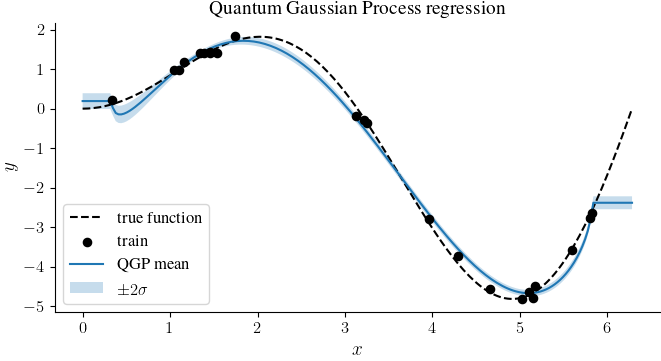

In [60]:
mean = y_scaler.inverse_transform(mean_scaled[:, None]).ravel()
std = std_scaled * y_scaler.scale_[0]

plt.figure(figsize=(7, 4))
plt.plot(X_test_raw[:, 0], y_test_clean_raw, "k--", label="true function")
plt.scatter(X_train_raw[:, 0], y_train_raw, color="k", s=35, zorder=3, label="train")
plt.plot(X_test_raw[:, 0], mean, label="QGP mean")
# plot posterior samples
# n_samples = 50
# samples = np.random.multivariate_normal(mean, cov_scaled, n_samples)
# for i in range(n_samples):
#     plt.plot(X_test_raw[:, 0], samples[i], lw=1, ls="--", alpha=0.5)

plt.fill_between(
    X_test_raw[:, 0],
    mean - 2 * std,
    mean + 2 * std,
    alpha=0.25,
    label=r"$\pm 2\sigma$",
)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Quantum Gaussian Process regression")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
def negative_log_marginal_likelihood(
    theta_flat,
    X_train,
    y_train,
    n_qubits=4,
    n_layers=2,
    noise_var=1e-2,
    jitter=1e-8,
    psd_correction=True,
):
    theta = theta_flat.reshape(n_layers, 2 * n_qubits)

    K = quantum_kernel_matrix(
        X_train,
        X_train,
        theta,
        n_qubits=n_qubits,
        n_layers=n_layers,
    )

    if psd_correction:
        K = psd_project(K)

    n = len(y_train)
    Ky = K + (noise_var + jitter) * np.eye(n)

    try:
        c_factor = cho_factor(Ky, lower=True, check_finite=False)
        alpha = cho_solve(c_factor, y_train, check_finite=False)

        data_fit = 0.5 * y_train @ alpha
        log_det = np.sum(np.log(np.diag(c_factor[0])))  # because logdet = 2 sum log diag(L)
        complexity = log_det
        constant = 0.5 * n * np.log(2.0 * np.pi)

        nlml = data_fit + complexity + constant

    except np.linalg.LinAlgError:
        nlml = 1e10

    return float(nlml)

In [62]:
theta0_flat = theta0.ravel()

initial_loss = negative_log_marginal_likelihood(
    theta0_flat,
    X_train,
    y_train,
    n_qubits=n_qubits,
    n_layers=n_layers,
    noise_var=noise_var,
)

print("Initial negative log marginal likelihood:", initial_loss)

Initial negative log marginal likelihood: 28.208650783451336


In [63]:
loss_history = []

def objective_with_logging(theta_flat):
    loss = negative_log_marginal_likelihood(
        theta_flat,
        X_train,
        y_train,
        n_qubits=n_qubits,
        n_layers=n_layers,
        noise_var=noise_var,
        psd_correction=True,
    )
    loss_history.append(loss)

    if len(loss_history) % 10 == 0:
        print(f"iter={len(loss_history):03d}, NLML={loss:.4f}")

    return loss


res = minimize(
    objective_with_logging,
    theta0_flat,
    method="Nelder-Mead",
    options={
        "maxiter": 100,
        "xatol": 1e-3,
        "fatol": 1e-3,
        "disp": True,
    },
)

theta_opt = res.x.reshape(n_layers, 2 * n_qubits)

print("Optimization success:", res.success)
print("Final NLML:", res.fun)

iter=010, NLML=26.8037
iter=020, NLML=27.4053
iter=030, NLML=26.6060
iter=040, NLML=24.5260
iter=050, NLML=23.1521
iter=060, NLML=21.2197
iter=070, NLML=19.9072
iter=080, NLML=17.8221
iter=090, NLML=16.2208
iter=100, NLML=14.2467
iter=110, NLML=12.7489
iter=120, NLML=10.6898
iter=130, NLML=9.5514
Optimization success: False
Final NLML: 7.907396734979077


/tmp/ipykernel_678635/4226347111.py:21: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = minimize(


/tmp/ipykernel_678635/1158600663.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


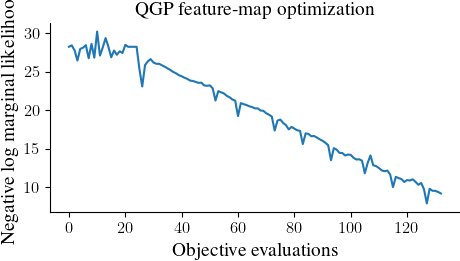

In [64]:
plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.xlabel("Objective evaluations")
plt.ylabel("Negative log marginal likelihood")
plt.title("QGP feature-map optimization")
plt.tight_layout()
plt.show()

/tmp/ipykernel_678635/3625070938.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


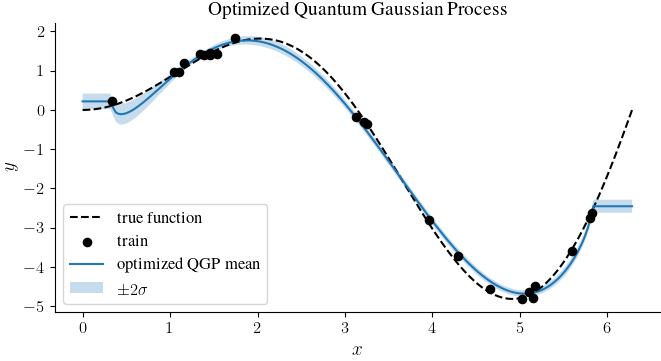

In [65]:
K_train_opt = quantum_kernel_matrix(X_train, X_train, theta_opt, n_qubits, n_layers)
K_test_train_opt = quantum_kernel_matrix(X_test, X_train, theta_opt, n_qubits, n_layers)
K_test_test_opt = quantum_kernel_matrix(X_test, X_test, theta_opt, n_qubits, n_layers)

K_train_opt = psd_project(K_train_opt)
K_test_test_opt = psd_project(K_test_test_opt)

mean_scaled_opt, var_scaled_opt, _ = gp_posterior_from_kernel(
    K_train=K_train_opt,
    K_test_train=K_test_train_opt,
    K_test_test=K_test_test_opt,
    y_train=y_train,
    noise_var=noise_var,
)

std_scaled_opt = np.sqrt(var_scaled_opt)

mean_opt = y_scaler.inverse_transform(mean_scaled_opt[:, None]).ravel()
std_opt = std_scaled_opt * y_scaler.scale_[0]

plt.figure(figsize=(7, 4))
plt.plot(X_test_raw[:, 0], y_test_clean_raw, "k--", label="true function")
plt.scatter(X_train_raw[:, 0], y_train_raw, color="k", s=35, zorder=3, label="train")
plt.plot(X_test_raw[:, 0], mean_opt, label="optimized QGP mean")
plt.fill_between(
    X_test_raw[:, 0],
    mean_opt - 2 * std_opt,
    mean_opt + 2 * std_opt,
    alpha=0.25,
    label=r"$\pm 2\sigma$",
)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.title("Optimized Quantum Gaussian Process")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
from sklearn.metrics import mean_squared_error, r2_score

mean_random = mean
mean_optimized = mean_opt

mse_random = mean_squared_error(y_test_clean_raw, mean_random)
mse_optimized = mean_squared_error(y_test_clean_raw, mean_optimized)

r2_random = r2_score(y_test_clean_raw, mean_random)
r2_optimized = r2_score(y_test_clean_raw, mean_optimized)

print(f"Random theta:    MSE={mse_random:.4f}, R2={r2_random:.4f}")
print(f"Optimized theta: MSE={mse_optimized:.4f}, R2={r2_optimized:.4f}")

Random theta:    MSE=0.1898, R2=0.9642
Optimized theta: MSE=0.1817, R2=0.9658


In [ ]:
def summarize_kernel(K, name="K"):
    eigvals = np.linalg.eigvalsh(0.5 * (K + K.T))
    off_diag = K[~np.eye(K.shape[0], dtype=bool)]

    print(f"\n{name}")
    print(f"  shape:              {K.shape}")
    print(f"  mean diagonal:      {np.mean(np.diag(K)):.6f}")
    print(f"  mean off-diagonal:  {np.mean(off_diag):.6f}")
    print(f"  std off-diagonal:   {np.std(off_diag):.6f}")
    print(f"  min eigenvalue:     {eigvals.min():.3e}")
    print(f"  max eigenvalue:     {eigvals.max():.3e}")
    print(f"  condition number:   {eigvals.max() / max(eigvals.min(), 1e-12):.3e}")


summarize_kernel(K_train, "Initial quantum kernel")
summarize_kernel(K_train_opt, "Optimized quantum kernel")


Initial quantum kernel
  shape:              (23, 23)
  mean diagonal:      1.000000
  mean off-diagonal:  0.645998
  std off-diagonal:   0.299768
  min eigenvalue:     -1.269e-15
  max eigenvalue:     1.553e+01
  condition number:   1.553e+13

Optimized quantum kernel
  shape:              (23, 23)
  mean diagonal:      1.000000
  mean off-diagonal:  0.596091
  std off-diagonal:   0.324866
  min eigenvalue:     1.000e-10
  max eigenvalue:     1.449e+01
  condition number:   1.449e+11


### Plot grid

In [68]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.linalg import cho_factor, cho_solve
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [69]:
def true_function(x):
    return x * np.sin(x)


def make_qgp_1d_data(
    n_train=23,
    n_test=250,
    noise_std=0.1,
    seed=123,
):
    rng = np.random.default_rng(seed)

    X_train = np.sort(rng.uniform(0.0, 2.0 * np.pi, size=n_train))[:, None]
    y_clean = true_function(X_train[:, 0])
    y_train = y_clean + noise_std * rng.normal(size=n_train)

    X_test = np.linspace(0.0, 2.0 * np.pi, n_test)[:, None]
    y_test_clean = true_function(X_test[:, 0])

    return X_train, y_train, X_test, y_test_clean


X_train_raw, y_train_raw, X_test_raw, y_test_clean_raw = make_qgp_1d_data(
    n_train=23,
    n_test=250,
    noise_std=0.1,
    seed=123,
)

# Scale x to [-1, 1], because the feature map uses arccos(x)
x_scaler = MinMaxScaler(feature_range=(-1.0, 1.0))
X_train = x_scaler.fit_transform(X_train_raw)
X_test = x_scaler.transform(X_test_raw)

# Standardize y for stable GP inference
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train_raw[:, None]).ravel()
y_test_clean = y_scaler.transform(y_test_clean_raw[:, None]).ravel()

In [70]:
def chebyshev_qgp_feature_map(x_scalar, theta, n_qubits=4, n_layers=2):
    """
    Chebyshev-inspired quantum feature map.

    x_scalar must be in [-1, 1].
    theta has shape [n_layers, 2 * n_qubits].
    """
    x_scalar = float(np.clip(x_scalar, -1.0, 1.0))
    theta = np.asarray(theta).reshape(n_layers, 2 * n_qubits)

    qc = QuantumCircuit(n_qubits)
    angle_x = np.arccos(x_scalar)

    for layer in range(n_layers):
        theta_layer = theta[layer]

        for q in range(n_qubits):
            theta_y = theta_layer[q]
            theta_z = theta_layer[n_qubits + q]

            qc.ry(theta_y, q)
            qc.rx(theta_y * angle_x, q)
            qc.rz(theta_z, q)
            qc.ry(theta_y, q)

    return qc


def compute_statevectors(X, theta, n_qubits=4, n_layers=2):
    states = []

    for x in X[:, 0]:
        qc = chebyshev_qgp_feature_map(
            x_scalar=x,
            theta=theta,
            n_qubits=n_qubits,
            n_layers=n_layers,
        )
        state = Statevector.from_instruction(qc).data
        states.append(state)

    return np.asarray(states)


def quantum_kernel_from_states(states_A, states_B):
    overlaps = states_A @ states_B.conj().T
    return np.abs(overlaps) ** 2


def quantum_kernel_matrix(XA, XB, theta, n_qubits=4, n_layers=2, signal_var=1.0):
    states_A = compute_statevectors(XA, theta, n_qubits=n_qubits, n_layers=n_layers)
    states_B = compute_statevectors(XB, theta, n_qubits=n_qubits, n_layers=n_layers)

    K = quantum_kernel_from_states(states_A, states_B)
    return signal_var * K

In [71]:
def gp_posterior_from_kernel(
    K_train,
    K_test_train,
    K_test_test,
    y_train,
    noise_var=1e-2,
    jitter=1e-8,
):
    n_train = K_train.shape[0]

    Ky = K_train + (noise_var + jitter) * np.eye(n_train)

    c_factor = cho_factor(Ky, lower=True, check_finite=False)
    alpha = cho_solve(c_factor, y_train, check_finite=False)

    mean = K_test_train @ alpha

    v = cho_solve(c_factor, K_test_train.T, check_finite=False)
    cov = K_test_test - K_test_train @ v
    cov = 0.5 * (cov + cov.T)

    var = np.clip(np.diag(cov), 1e-12, None)

    return mean, var, cov


def unpack_params(params, n_qubits, n_layers):
    """
    params = [theta_flat, log_signal_var, log_noise_var]
    """
    n_theta = n_layers * 2 * n_qubits

    theta = params[:n_theta].reshape(n_layers, 2 * n_qubits)
    log_signal_var = params[n_theta]
    log_noise_var = params[n_theta + 1]

    signal_var = np.exp(log_signal_var)
    noise_var = np.exp(log_noise_var)

    return theta, signal_var, noise_var


def negative_log_marginal_likelihood(
    params,
    X_train,
    y_train,
    n_qubits,
    n_layers,
    jitter=1e-8,
):
    theta, signal_var, noise_var = unpack_params(params, n_qubits, n_layers)

    K = quantum_kernel_matrix(
        X_train,
        X_train,
        theta,
        n_qubits=n_qubits,
        n_layers=n_layers,
        signal_var=signal_var,
    )

    n = len(y_train)
    Ky = K + (noise_var + jitter) * np.eye(n)

    try:
        c_factor = cho_factor(Ky, lower=True, check_finite=False)
        alpha = cho_solve(c_factor, y_train, check_finite=False)

        data_fit = 0.5 * y_train @ alpha
        log_det = np.sum(np.log(np.diag(c_factor[0])))
        constant = 0.5 * n * np.log(2.0 * np.pi)

        nlml = data_fit + log_det + constant

        if not np.isfinite(nlml):
            return 1e10

        return float(nlml)

    except Exception:
        return 1e10

In [72]:
def spsa_minimize(
    objective,
    x0,
    maxiter=80,
    a=0.05,
    c=0.10,
    alpha=0.602,
    gamma=0.101,
    seed=0,
    callback=None,
):
    rng = np.random.default_rng(seed)

    x = x0.copy()
    history = []

    for k in range(1, maxiter + 1):
        ak = a / (k ** alpha)
        ck = c / (k ** gamma)

        delta = rng.choice([-1.0, 1.0], size=x.shape)

        loss_plus = objective(x + ck * delta)
        loss_minus = objective(x - ck * delta)

        ghat = (loss_plus - loss_minus) / (2.0 * ck) * delta

        x = x - ak * ghat

        # Keep log-parameters in a numerically safe range
        x[-2] = np.clip(x[-2], -5.0, 5.0)    # log signal variance
        x[-1] = np.clip(x[-1], -8.0, 2.0)    # log noise variance

        loss = objective(x)
        history.append(loss)

        if callback is not None:
            callback(k, loss)

    return x, np.asarray(history)

In [73]:
def evaluate_qgp(
    X_train,
    y_train,
    X_test,
    y_test_clean_raw,
    y_scaler,
    theta,
    n_qubits,
    n_layers,
    signal_var,
    noise_var,
):
    K_train = quantum_kernel_matrix(
        X_train,
        X_train,
        theta,
        n_qubits=n_qubits,
        n_layers=n_layers,
        signal_var=signal_var,
    )

    K_test_train = quantum_kernel_matrix(
        X_test,
        X_train,
        theta,
        n_qubits=n_qubits,
        n_layers=n_layers,
        signal_var=signal_var,
    )

    K_test_test = quantum_kernel_matrix(
        X_test,
        X_test,
        theta,
        n_qubits=n_qubits,
        n_layers=n_layers,
        signal_var=signal_var,
    )

    mean_scaled, var_scaled, _ = gp_posterior_from_kernel(
        K_train=K_train,
        K_test_train=K_test_train,
        K_test_test=K_test_test,
        y_train=y_train,
        noise_var=noise_var,
    )

    std_scaled = np.sqrt(var_scaled)

    mean_raw = y_scaler.inverse_transform(mean_scaled[:, None]).ravel()
    std_raw = std_scaled * y_scaler.scale_[0]

    rmse = np.sqrt(mean_squared_error(y_test_clean_raw, mean_raw))

    return mean_raw, std_raw, rmse

In [74]:
results_dir = Path("../results/qgp_layers_qubits")
results_dir.mkdir(parents=True, exist_ok=True)

qubit_values = [4, 8]
layer_values = [2, 4, 8]

base_seed = 123
maxiter_spsa = 80

summary_rows = []

for n_qubits in qubit_values:
    for n_layers in layer_values:

        print("\n" + "=" * 80)
        print(f"Training QGP: n_qubits={n_qubits}, n_layers={n_layers}")
        print("=" * 80)

        rng = np.random.default_rng(base_seed + 100 * n_qubits + n_layers)

        # ------------------------------------------------------------
        # Initialize parameters
        # ------------------------------------------------------------
        theta0 = rng.normal(
            loc=0.0,
            scale=0.5,
            size=(n_layers, 2 * n_qubits),
        )

        signal_var0 = 1.0
        noise_var0 = 0.03

        params0 = np.concatenate([
            theta0.ravel(),
            np.array([np.log(signal_var0), np.log(noise_var0)]),
        ])

        # ------------------------------------------------------------
        # Evaluate untrained model
        # ------------------------------------------------------------
        mean_untrained, std_untrained, rmse_untrained = evaluate_qgp(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test_clean_raw=y_test_clean_raw,
            y_scaler=y_scaler,
            theta=theta0,
            n_qubits=n_qubits,
            n_layers=n_layers,
            signal_var=signal_var0,
            noise_var=noise_var0,
        )

        print(f"Untrained RMSE: {rmse_untrained:.4f}")

        # ------------------------------------------------------------
        # Optimize by marginal likelihood
        # ------------------------------------------------------------
        def objective(params):
            return negative_log_marginal_likelihood(
                params=params,
                X_train=X_train,
                y_train=y_train,
                n_qubits=n_qubits,
                n_layers=n_layers,
            )

        loss_history = []

        def callback(k, loss):
            loss_history.append(loss)
            if k % 10 == 0:
                print(f"iter={k:03d}, NLML={loss:.4f}")

        t0 = time.time()

        params_opt, loss_history = spsa_minimize(
            objective=objective,
            x0=params0,
            maxiter=maxiter_spsa,
            a=0.03,
            c=0.10,
            seed=base_seed + n_qubits + n_layers,
            callback=callback,
        )

        train_time_sec = time.time() - t0

        theta_opt, signal_var_opt, noise_var_opt = unpack_params(
            params_opt,
            n_qubits=n_qubits,
            n_layers=n_layers,
        )

        # ------------------------------------------------------------
        # Evaluate trained model
        # ------------------------------------------------------------
        mean_trained, std_trained, rmse_trained = evaluate_qgp(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test_clean_raw=y_test_clean_raw,
            y_scaler=y_scaler,
            theta=theta_opt,
            n_qubits=n_qubits,
            n_layers=n_layers,
            signal_var=signal_var_opt,
            noise_var=noise_var_opt,
        )

        print(f"Trained RMSE:   {rmse_trained:.4f}")
        print(f"signal_var_opt: {signal_var_opt:.4f}")
        print(f"noise_var_opt:  {noise_var_opt:.6f}")
        print(f"train time:     {train_time_sec:.2f} sec")

        # ------------------------------------------------------------
        # Save model-specific results
        # ------------------------------------------------------------
        out_file = results_dir / f"qgp_qubits-{n_qubits}_layers-{n_layers}.npz"

        np.savez(
            out_file,
            n_qubits=n_qubits,
            n_layers=n_layers,
            X_train_raw=X_train_raw,
            y_train_raw=y_train_raw,
            X_test_raw=X_test_raw,
            y_test_clean_raw=y_test_clean_raw,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test_clean=y_test_clean,
            theta0=theta0,
            theta_opt=theta_opt,
            signal_var0=signal_var0,
            noise_var0=noise_var0,
            signal_var_opt=signal_var_opt,
            noise_var_opt=noise_var_opt,
            mean_untrained=mean_untrained,
            std_untrained=std_untrained,
            rmse_untrained=rmse_untrained,
            mean_trained=mean_trained,
            std_trained=std_trained,
            rmse_trained=rmse_trained,
            loss_history=loss_history,
            train_time_sec=train_time_sec,
        )

        summary_rows.append({
            "n_qubits": n_qubits,
            "n_layers": n_layers,
            "rmse_untrained": rmse_untrained,
            "rmse_trained": rmse_trained,
            "signal_var0": signal_var0,
            "noise_var0": noise_var0,
            "signal_var_opt": signal_var_opt,
            "noise_var_opt": noise_var_opt,
            "train_time_sec": train_time_sec,
            "path": str(out_file),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(results_dir / "summary.csv", index=False)

summary_df


Training QGP: n_qubits=4, n_layers=2
Untrained RMSE: 1.2018
iter=010, NLML=-10.5589
iter=020, NLML=-11.6709
iter=030, NLML=-13.4340
iter=040, NLML=-13.8792
iter=050, NLML=-14.6968
iter=060, NLML=-15.4109
iter=070, NLML=-15.7938
iter=080, NLML=-16.4716
Trained RMSE:   0.4292
signal_var_opt: 0.4869
noise_var_opt:  0.001577
train time:     21.40 sec

Training QGP: n_qubits=4, n_layers=4
Untrained RMSE: 0.8887
iter=010, NLML=-11.6795
iter=020, NLML=-14.8683
iter=030, NLML=-16.3538
iter=040, NLML=-16.9072
iter=050, NLML=-18.5136
iter=060, NLML=-19.0265
iter=070, NLML=-19.5240
iter=080, NLML=-19.6320
Trained RMSE:   0.4217
signal_var_opt: 1.3052
noise_var_opt:  0.002628
train time:     37.21 sec

Training QGP: n_qubits=4, n_layers=8
Untrained RMSE: 0.5846
iter=010, NLML=-9.9469
iter=020, NLML=-13.3885
iter=030, NLML=-13.7680
iter=040, NLML=-15.9179
iter=050, NLML=-16.2006
iter=060, NLML=-17.1184
iter=070, NLML=-18.5012
iter=080, NLML=-19.0165
Trained RMSE:   0.4183
signal_var_opt: 1.3906
no

,n_qubits,n_layers,rmse_untrained,rmse_trained,signal_var0,noise_var0,signal_var_opt,noise_var_opt,train_time_sec,path
0,4,2,1.201782,0.429161,1.0,0.03,0.486882,0.001577,21.399105,../results/qgp_layers_qubits/qgp_qubits-4_laye...
1,4,4,0.888750,0.421695,1.0,0.03,1.305192,0.002628,37.209330,../results/qgp_layers_qubits/qgp_qubits-4_laye...
2,4,8,0.584581,0.418292,1.0,0.03,1.390650,0.002725,69.788031,../results/qgp_layers_qubits/qgp_qubits-4_laye...
3,8,2,0.571539,0.409632,1.0,0.03,2.273657,0.004590,43.023659,../results/qgp_layers_qubits/qgp_qubits-8_laye...
4,8,4,0.515307,0.424184,1.0,0.03,1.035790,0.001950,82.112221,../results/qgp_layers_qubits/qgp_qubits-8_laye...
5,8,8,0.414707,0.419213,1.0,0.03,0.814070,0.003023,158.477077,../results/qgp_layers_qubits/qgp_qubits-8_laye...


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("../results/qgp_layers_qubits")

qubit_values = [4, 8]
layer_values = [2, 4, 8]

summary_df = pd.read_csv(results_dir / "summary.csv")
summary_df

,n_qubits,n_layers,rmse_untrained,rmse_trained,signal_var0,noise_var0,signal_var_opt,noise_var_opt,train_time_sec,path
0,4,2,1.201782,0.429161,1.0,0.03,0.486882,0.001577,21.399105,../results/qgp_layers_qubits/qgp_qubits-4_laye...
1,4,4,0.888750,0.421695,1.0,0.03,1.305192,0.002628,37.209330,../results/qgp_layers_qubits/qgp_qubits-4_laye...
2,4,8,0.584581,0.418292,1.0,0.03,1.390650,0.002725,69.788031,../results/qgp_layers_qubits/qgp_qubits-4_laye...
3,8,2,0.571539,0.409632,1.0,0.03,2.273657,0.004590,43.023659,../results/qgp_layers_qubits/qgp_qubits-8_laye...
4,8,4,0.515307,0.424184,1.0,0.03,1.035790,0.001950,82.112221,../results/qgp_layers_qubits/qgp_qubits-8_laye...
5,8,8,0.414707,0.419213,1.0,0.03,0.814070,0.003023,158.477077,../results/qgp_layers_qubits/qgp_qubits-8_laye...


/tmp/ipykernel_678635/3904105168.py:130: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


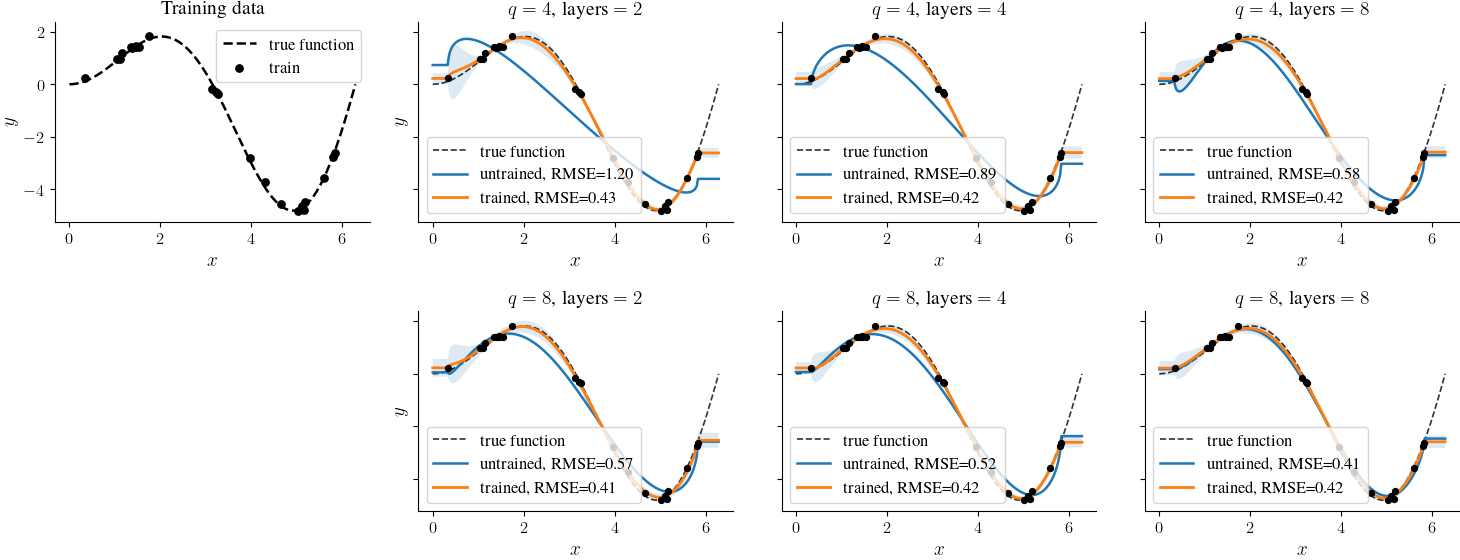

In [78]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(15, 6),
    sharex=False,
    sharey=True,
)

# ------------------------------------------------------------
# Top-left: data and true function
# ------------------------------------------------------------
ax = axes[0, 0]

first_file = results_dir / "qgp_qubits-4_layers-2.npz"
data0 = np.load(first_file)

X_train_raw = data0["X_train_raw"]
y_train_raw = data0["y_train_raw"]
X_test_raw = data0["X_test_raw"]
y_test_clean_raw = data0["y_test_clean_raw"]

ax.plot(
    X_test_raw[:, 0],
    y_test_clean_raw,
    "k--",
    linewidth=1.8,
    label="true function",
)

ax.scatter(
    X_train_raw[:, 0],
    y_train_raw,
    color="k",
    s=28,
    zorder=3,
    label="train",
)

ax.set_title("Training data")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend(frameon=True)

# ------------------------------------------------------------
# Bottom-left: empty
# ------------------------------------------------------------
axes[1, 0].axis("off")

# ------------------------------------------------------------
# Remaining 2x3 block: QGP predictions
# ------------------------------------------------------------
for row_idx, n_qubits in enumerate(qubit_values):
    for col_idx, n_layers in enumerate(layer_values):

        ax = axes[row_idx, col_idx + 1]

        file_path = results_dir / f"qgp_qubits-{n_qubits}_layers-{n_layers}.npz"
        data = np.load(file_path)

        X_train_raw = data["X_train_raw"]
        y_train_raw = data["y_train_raw"]
        X_test_raw = data["X_test_raw"]
        y_test_clean_raw = data["y_test_clean_raw"]

        mean_untrained = data["mean_untrained"]
        mean_trained = data["mean_trained"]

        std_untrained = data["std_untrained"]
        std_trained = data["std_trained"]

        rmse_untrained = float(data["rmse_untrained"])
        rmse_trained = float(data["rmse_trained"])

        # True function
        ax.plot(
            X_test_raw[:, 0],
            y_test_clean_raw,
            "k--",
            linewidth=1.2,
            alpha=0.8,
            label="true function",
        )

        # Training points
        ax.scatter(
            X_train_raw[:, 0],
            y_train_raw,
            color="k",
            s=18,
            zorder=3,
        )

        # Untrained QGP
        ax.plot(
            X_test_raw[:, 0],
            mean_untrained,
            linestyle="-",
            linewidth=1.8,
            label=rf"untrained, RMSE={rmse_untrained:.2f}",
        )

        # Trained QGP
        ax.plot(
            X_test_raw[:, 0],
            mean_trained,
            linestyle="-",
            linewidth=2.0,
            label=rf"trained, RMSE={rmse_trained:.2f}",
        )

        # Optional uncertainty band for trained model
        ax.fill_between(
            X_test_raw[:, 0],
            mean_trained - 2.0 * std_trained,
            mean_trained + 2.0 * std_trained,
            alpha=0.15,
            linewidth=0,
        )

        ax.set_title(rf"$q={n_qubits}$, layers $={n_layers}$")
        ax.set_xlabel(r"$x$")

        if col_idx == 0:
            ax.set_ylabel(r"$y$")

        ax.legend(frameon=True, loc="best")

#fig.suptitle("Quantum Gaussian Process regression with trained and untrained quantum kernels", y=1.02)

plt.tight_layout()
plt.savefig(results_dir / "qgp_qubits_layers_grid.pdf", bbox_inches="tight")
plt.savefig(results_dir / "qgp_qubits_layers_grid.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_678635/720706377.py:181: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.06, 1, 1])


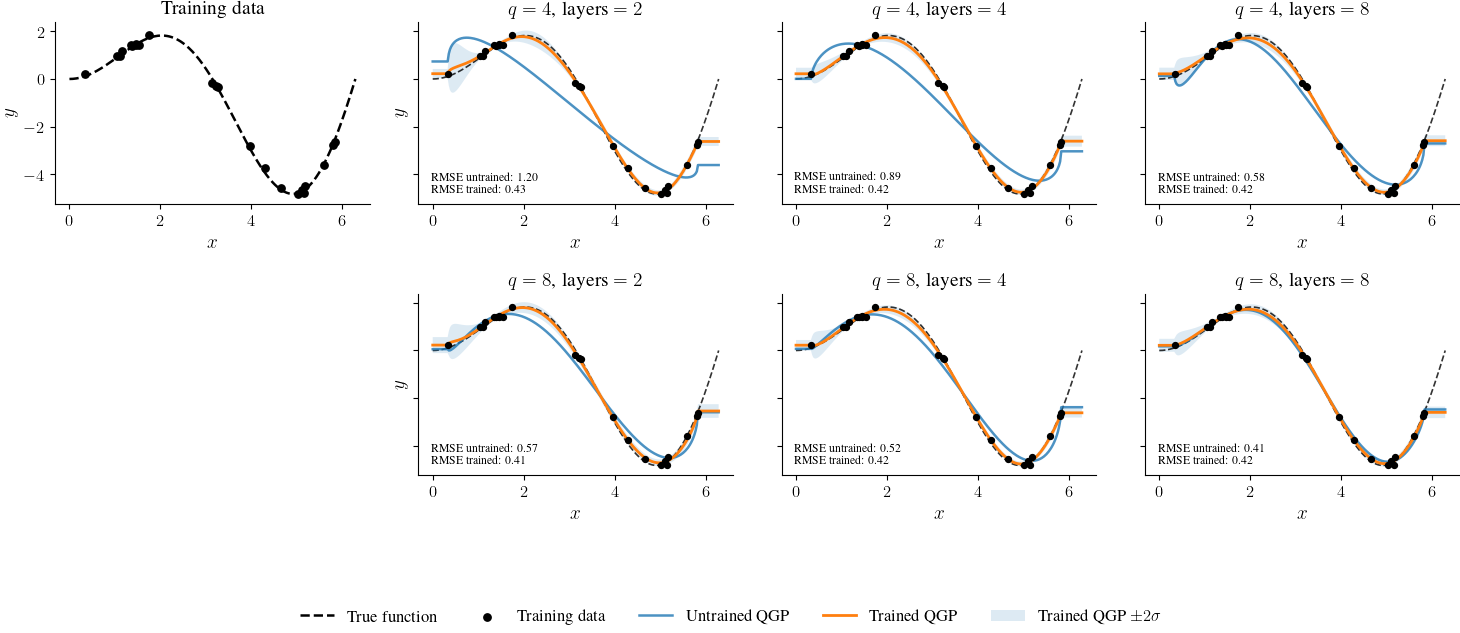

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(15, 6),
    sharex=False,
    sharey=True,
)

# ------------------------------------------------------------
# Top-left: data and true function
# ------------------------------------------------------------
ax = axes[0, 0]

first_file = results_dir / "qgp_qubits-4_layers-2.npz"
data0 = np.load(first_file)

X_train_raw = data0["X_train_raw"]
y_train_raw = data0["y_train_raw"]
X_test_raw = data0["X_test_raw"]
y_test_clean_raw = data0["y_test_clean_raw"]

line_true, = ax.plot(
    X_test_raw[:, 0],
    y_test_clean_raw,
    "k--",
    linewidth=1.8,
    label="True function",
)

scatter_train = ax.scatter(
    X_train_raw[:, 0],
    y_train_raw,
    color="k",
    s=28,
    zorder=3,
    label="Training data",
)

ax.set_title("Training data")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

# No individual legend here
ax.legend_.remove() if ax.get_legend() is not None else None

# ------------------------------------------------------------
# Bottom-left: empty
# ------------------------------------------------------------
axes[1, 0].axis("off")

# ------------------------------------------------------------
# Remaining 2x3 block: QGP predictions
# ------------------------------------------------------------
line_untrained = None
line_trained = None
band_trained = None

for row_idx, n_qubits in enumerate(qubit_values):
    for col_idx, n_layers in enumerate(layer_values):

        ax = axes[row_idx, col_idx + 1]

        file_path = results_dir / f"qgp_qubits-{n_qubits}_layers-{n_layers}.npz"
        data = np.load(file_path)

        X_train_raw = data["X_train_raw"]
        y_train_raw = data["y_train_raw"]
        X_test_raw = data["X_test_raw"]
        y_test_clean_raw = data["y_test_clean_raw"]

        mean_untrained = data["mean_untrained"]
        mean_trained = data["mean_trained"]

        std_trained = data["std_trained"]

        rmse_untrained = float(data["rmse_untrained"])
        rmse_trained = float(data["rmse_trained"])

        # True function
        ax.plot(
            X_test_raw[:, 0],
            y_test_clean_raw,
            "k--",
            linewidth=1.2,
            alpha=0.8,
        )

        # Training points
        ax.scatter(
            X_train_raw[:, 0],
            y_train_raw,
            color="k",
            s=18,
            zorder=3,
        )

        # Untrained QGP
        line_untrained, = ax.plot(
            X_test_raw[:, 0],
            mean_untrained,
            linestyle="-",
            linewidth=1.8,
            alpha=0.8,
            label="Untrained QGP",
        )

        # Trained QGP
        line_trained, = ax.plot(
            X_test_raw[:, 0],
            mean_trained,
            linestyle="-",
            linewidth=2.0,
            label="Trained QGP",
        )

        # Uncertainty band for trained model
        band_trained = ax.fill_between(
            X_test_raw[:, 0],
            mean_trained - 2.0 * std_trained,
            mean_trained + 2.0 * std_trained,
            alpha=0.15,
            linewidth=0,
            label=r"Trained QGP $\pm 2\sigma$",
        )

        # RMSE annotation
        ax.text(
            0.04,
            0.05,
            rf"RMSE untrained: {rmse_untrained:.2f}" "\n"
            rf"RMSE trained: {rmse_trained:.2f}",
            transform=ax.transAxes,
            fontsize=8.5,
            verticalalignment="bottom",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
                edgecolor="none",
            ),
        )

        ax.set_title(rf"$q={n_qubits}$, layers $={n_layers}$")
        ax.set_xlabel(r"$x$")

        if col_idx == 0:
            ax.set_ylabel(r"$y$")

        # Remove subplot legends
        if ax.get_legend() is not None:
            ax.get_legend().remove()

# ------------------------------------------------------------
# Common legend
# ------------------------------------------------------------
handles = [
    line_true,
    scatter_train,
    line_untrained,
    line_trained,
    band_trained,
]

labels = [
    "True function",
    "Training data",
    "Untrained QGP",
    "Trained QGP",
    r"Trained QGP $\pm 2\sigma$",
]

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.001),
    ncol=5,
    frameon=False,
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(results_dir / "qgp_qubits_layers_grid.pdf", bbox_inches="tight")
plt.savefig(results_dir / "qgp_qubits_layers_grid.png", dpi=300, bbox_inches="tight")
plt.show()